<a href="https://colab.research.google.com/github/abhisakh/XGBOOST_Machine_Leraning_Predictor_Titanic/blob/main/Synthetic_Data_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Machine Learning Pipeline:
Complete Research Framework
Clinical-Epidemiological Disease Burden & Mortality Prediction
Project Scope
This notebook implements a comprehensive two-path ML pipeline with:

**Path A:** Disease Burden Regression (total_diagnoses count)

**Path B:** Mortality Risk Classification (binary is_deceased)
Advanced Comparisons: 4 different architectural approaches
Performance Leaderboard: ROC-AUC vs PR-AUC rankings

**Interpretability:** SHAP values and feature attribution

# Necessary module import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve,
    precision_score, recall_score, roc_curve
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
print('✓ All libraries imported')

✓ All libraries imported


# Data Import

In [3]:
url = 'https://raw.githubusercontent.com/abhisakh/XGBOOST_Machine_Leraning_Predictor_Titanic/refs/heads/main/data/NODE_A_unified.csv'
df = pd.read_csv(url)

# Data Overview

In [4]:
df.head()

,id,age,birth_date,sex,region,urban_rural,household_id,household_size,income_quartile,estimated_income,...,total_billing_scheine,total_hospital_stays,total_hospital_cost,total_interventions,avg_treatment_effect,has_counterfactual_record,dmp_program_count,total_dmp_visits,total_switches,is_deceased
0,1,77,1947-07-02,M,NRW,urban,7513,2,Q1,10000.0,...,19.0,0.0,0.00,4.0,0.0,7,0.0,0.0,0.0,0.0
1,2,15,2009-12-13,F,NRW,urban,2417,1,Q2,0.0,...,0.0,0.0,0.00,0.0,0.0,7,0.0,0.0,1.0,0.0
2,3,53,1971-11-10,F,NRW,urban,5723,2,Q4,67643.0,...,1.0,2.0,13818.96,5.0,0.0,7,2.0,26.0,0.0,0.0
3,4,60,1964-07-13,M,NRW,urban,6307,5,Q4,65053.0,...,0.0,0.0,0.00,2.0,0.0,7,0.0,0.0,0.0,0.0
4,5,31,1993-08-07,F,RP,rural,3880,1,Q3,44246.0,...,0.0,0.0,0.00,0.0,0.0,7,0.0,0.0,0.0,0.0


# Column names

In [5]:
print(df.columns)

Index(['id', 'age', 'birth_date', 'sex', 'region', 'urban_rural',
       'household_id', 'household_size', 'income_quartile', 'estimated_income',
       'education', 'employment_status', 'migration_background', 'zip_code',
       'gisd_quintile', 'insurance_fund', 'insurance_status',
       'insurance_start', 'insurance_end', 'exposome_air_quality',
       'exposome_green_space', 'exposome_noise_level', 'exposome_deprivation',
       'total_diagnoses', 'confirmed_diagnoses', 'total_ambulatory_visits',
       'total_prescriptions', 'total_drug_cost', 'total_billing_scheine',
       'total_hospital_stays', 'total_hospital_cost', 'total_interventions',
       'avg_treatment_effect', 'has_counterfactual_record',
       'dmp_program_count', 'total_dmp_visits', 'total_switches',
       'is_deceased'],
      dtype='object')


# 📊 Exploratory Data Analysis (EDA):
<h1>Non-Numeric Features</h1>
<h2>💡 Motivation & Objective</h2>
<p>Machine learning models are mathematical frameworks that require numerical inputs. Raw text labels cannot be parsed directly by our algorithms. Therefore, before we can proceed to model training, we must identify, inspect, and prepare our non-numeric columns.</p>
<br><h3>We perform an inspection of unique categories to achieve three primary goals:</h3>

1. Determine Encoding Strategy: Identify which variablesare binary (two categories), ordinal (ordered categories, like education level), or nominal (unordered text, like region) so we can map them to numbers using the right method (e.g., One-Hot Encoding vs. Ordinal Mapping).
2. Assess Cardinality: Identify columns with high cardinality (too many unique categories). High cardinality can lead to the "curse of dimensionality" if we split them into too many columns, which dramatically slows down training and risks overfitting.
3. Data Quality Check: Uncover data-entry typos (e.g., inconsistent formatting, casing variations) and hidden missing-value placeholders (e.g., strings like "Unknown", "?", or "None") that standard automated scripts might miss.

<h2>📈 Analytical Steps to ExecuteIdentify Data Types:</h2>
<p>Compile a comprehensive list of columns stored as object or text formats.

1. Identify Data Types: Compile a comprehensive list of columns stored as object or text formats.
2. Count and List Unique Labels: Examine the distinct text expressions within each column using .unique() and calculate total counts using .nunique().
3. Feature Engineering Isolation: Flag date-related fields (birth_date, insurance_start, insurance_end) to transform them later into operational numerical durations (such as calculating age or length of insurance coverage).</p>

# 1. Identify Data Types: Columns containing non-numeric values

In [6]:
non_numeric_features = [feature for feature in df.columns if df[feature].dtype == object ]
for feature in non_numeric_features:
  print(feature,'::', df[feature].dtype)

birth_date :: object
sex :: object
region :: object
urban_rural :: object
income_quartile :: object
education :: object
employment_status :: object
migration_background :: object
insurance_fund :: object
insurance_status :: object
insurance_start :: object
insurance_end :: object


# 2. Count and List Unique Labels

In [7]:
non_numeric_features = [feature for feature in df.columns if df[feature].dtype == object]

for feature in non_numeric_features:
    unique_vals = list(df[feature].unique())
    num_unique = df[feature].nunique()

    # If there are more than 5 unique items, show a preview instead of flooding the screen
    if len(unique_vals) > 5:
        preview = f"{unique_vals[:5]} ... [and {len(unique_vals)-5} more]"
    else:
        preview = f"{unique_vals}"

    print(f"{feature:<22} :: {num_unique:<5} categories => {preview}")


birth_date             :: 11619 categories => ['1947-07-02', '2009-12-13', '1971-11-10', '1964-07-13', '1993-08-07'] ... [and 11614 more]
sex                    :: 2     categories => ['M', 'F']
region                 :: 16    categories => ['NRW', 'RP', 'BW', 'BE', 'NI'] ... [and 11 more]
urban_rural            :: 2     categories => ['urban', 'rural']
income_quartile        :: 4     categories => ['Q1', 'Q2', 'Q4', 'Q3']
education              :: 8     categories => ['ISCED_5', 'ISCED_2', 'ISCED_6', 'ISCED_3', 'ISCED_4'] ... [and 3 more]
employment_status      :: 4     categories => ['retired', 'other', 'employed', 'unemployed']
migration_background   :: 3     categories => ['second_generation', 'none', 'first_generation']
insurance_fund         :: 1     categories => ['NODE_A']
insurance_status       :: 4     categories => ['KVdR', 'Familienversichert', 'Pflichtmitglied', 'Freiwillig Versicherter']
insurance_start        :: 2188  categories => ['2019-07-31', '2020-08-08', '2023-08-0

<h1>🗑️ 1. Drop Invariant Columns (Zero Information)</h1>
<p>
insurance_fund (1 category):
Since every single row is 'NODE_A', this column provides zero variance or predictive power.Action: Drop it completely using df.drop(columns=['insurance_fund'], inplace=True).</p>
<h1>📅 2. Transform Date Fields into Durationsbirth_date (11,619 categories):</h1>
<p>Do not encode this as a category. Calculate the patient's age relative to a target reference date or current year.insurance_start & insurance_end: Calculate the actual coverage duration by subtracting start from end: insurance_end - insurance_start.</p>

<h1>🏷️ 3. Encode Categories with 2 Options (Binary Mapping)sex & urban_rural (2 categories):</h1>
<p>
Perfect for simple binary mapping to 0 and 1. <br> Action: Map 'M'/'urban' to 1 and 'F'/'rural' to 0.</p>

<h1>📶 4. Ordinal Categories (Ordered Levels)income_quartile (4 categories):</h1>
<p>
 These have a natural mathematical order (Q1 < Q2 < Q3 < Q4).<br>Action: Map them explicitly to integers: {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}.education (8 categories):<br> These follow the international ISCED standard. Higher numbers mean a higher level of education (e.g., ISCED 6 is a Bachelor's level, ISCED 2 is lower secondary). We should map these ordinally based on their numeric value.</p>

 <h1>🗺️ 5. Nominal Categories (Unordered Levels)region (16 categories):</h1>
 <p>These are the 16 German federal states (e.g., NRW = North Rhine-Westphalia, BW = Baden-Württemberg).employment_status, migration_background, insurance_status: Unordered textual buckets.<br>Action: Use One-Hot Encoding (pd.get_dummies()) for these columns since their unique value counts are low enough to avoid hurting your model's speed.</p>

#We already have the column for the Age. So we don't need the Date of Birth column.

*   Convert Insurence Start, End Date to proper date format and add Insurance Days
*   Delete Date of birth, Insurance Start, End, Insurance fund
*   Encode Categories with 2 Options (Binary Mapping)sex & urban_rural (2 categories): 0 and 1



In [8]:
# Create a clean working copy of your dataframe
df_work = df.copy()

# 1. Convert insurance dates from text strings to true datetime formats
df_work['insurance_start'] = pd.to_datetime(df_work['insurance_start'])
df_work['insurance_end'] = pd.to_datetime(df_work['insurance_end'])

# 2. Engineer a new numerical feature: Insurance duration in days
df_work['insurance_duration_days'] = (df_work['insurance_end'] - df_work['insurance_start']).dt.days

# 3. Drop columns that are redundant, uninformative, or raw dates
columns_to_drop = ['birth_date', 'insurance_fund', 'insurance_start', 'insurance_end']
df_work.drop(columns=columns_to_drop, inplace=True)

# 4. Map Sex to 1 (Male) and 0 (Female) using .map()
df_work['sex'] = df_work['sex'].map({'M': 1, 'F': 0})

# 5. Map urban_rural to 1 (urban) and 0 (rural) using .map()
df_work['urban_rural'] = df_work['urban_rural'].map({'urban': 1, 'rural': 0})

# 6. Convert income_quartile to integers 1-4 using .map()
df_work['income_quartile'] = df_work['income_quartile'].map({'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4})

# 7. Convert Education to 8 ordinal categories (ISCED 1 to 8)
education_mapping = {
    'ISCED_1': 1, 'ISCED_2': 2, 'ISCED_3': 3, 'ISCED_4': 4,
    'ISCED_5': 5, 'ISCED_6': 6, 'ISCED_7': 7, 'ISCED_8': 8
}
df_work['education'] = df_work['education'].map(education_mapping)

# --- BASELINE LOGGING SYSTEM ---
# Tracks and prints dropped categories before encoding takes place
nominal_cols = ['region', 'employment_status', 'migration_background', 'insurance_status']

print("📝 --- ONE-HOT ENCODING TRACKING LOG ---")
for col in nominal_cols:
    all_categories = sorted(df_work[col].dropna().unique())
    dropped_baseline = all_categories[0]
    kept_features = all_categories[1:]
    print(f"🔹 Column '{col}':")
    print(f"   ❌ DROPPED (Baseline Reference) -> {dropped_baseline}")
    print(f"   ✅ KEPT (New Dummy Columns)    -> {kept_features}\n")
print("="*50 + "\n")

# 8. Nominal Categories: One-Hot Encoding for remaining text columns
# Using drop_first=True to avoid collinearity/dummy variable trap
df_work = pd.get_dummies(df_work, columns=nominal_cols, drop_first=True, dtype=int)

# Verify the final dataset profile
print(f"Final Dataframe Shape: {df_work.shape}")
print("\nRemaining features in processed dataframe:")
print(df_work.columns.tolist())


📝 --- ONE-HOT ENCODING TRACKING LOG ---
🔹 Column 'region':
   ❌ DROPPED (Baseline Reference) -> BB
   ✅ KEPT (New Dummy Columns)    -> ['BE', 'BW', 'BY', 'HB', 'HE', 'HH', 'MV', 'NI', 'NRW', 'RP', 'SH', 'SL', 'SN', 'ST', 'TH']

🔹 Column 'employment_status':
   ❌ DROPPED (Baseline Reference) -> employed
   ✅ KEPT (New Dummy Columns)    -> ['other', 'retired', 'unemployed']

🔹 Column 'migration_background':
   ❌ DROPPED (Baseline Reference) -> first_generation
   ✅ KEPT (New Dummy Columns)    -> ['none', 'second_generation']

🔹 Column 'insurance_status':
   ❌ DROPPED (Baseline Reference) -> Familienversichert
   ✅ KEPT (New Dummy Columns)    -> ['Freiwillig Versicherter', 'KVdR', 'Pflichtmitglied']


Final Dataframe Shape: (15000, 54)

Remaining features in processed dataframe:
['id', 'age', 'sex', 'urban_rural', 'household_id', 'household_size', 'income_quartile', 'estimated_income', 'education', 'zip_code', 'gisd_quintile', 'exposome_air_quality', 'exposome_green_space', 'exposome_nois

# 📈 Phase 1: Relationships with Continuous Targets (total_diagnoses)
<h1>A. Continuous Features vs. total_diagnoses (Correlation & Scatter)</h1>
<p>Look at continuous variables like estimated_income, healthcare utilization indicators (total_prescriptions, total_hospital_stays), and environmental risk factors (exposome_air_quality, exposome_noise_level).</p>

<h3>Method: </h3>
<p>Calculate a Pearson correlation matrix and look at the row/column for total_diagnoses.</p>

<h3>What to expect:</h3>
<p>You will likely see a strong positive correlation between total_diagnoses and utilization metrics (e.g., more hospital stays = more diagnoses).</p>

<h1>B. Discrete/Categorical Features vs
total_diagnoses (Boxplots)</h1>
<p>Look at features like sex, urban_rural, income_quartile, education, and employment_status.</p>

<h3>Method:</h3>
<p>Use Boxplots or Violin plots grouped by category.</p>
  
<h3>What to look for:</h3>
<p>Does the median number of total_diagnoses shift significantly between employed vs. retired individuals? Does it differ by income_quartile?</p>

In [9]:
# Select a subset of highly relevant continuous numeric columns
continuous_cols = [
    'age', 'estimated_income', 'household_size',
    'exposome_air_quality', 'exposome_green_space', 'exposome_noise_level', 'exposome_deprivation',
    'total_prescriptions', 'total_hospital_stays', 'total_drug_cost', 'insurance_duration_days',
    'total_diagnoses'  # include target
]

# Calculate correlations
correlations = df_work[continuous_cols].corr()['total_diagnoses'].sort_values(ascending=False)

print("📊 Correlation of continuous features with total_diagnoses:")
print(correlations)


📊 Correlation of continuous features with total_diagnoses:
total_diagnoses            1.000000
total_prescriptions        0.796586
total_drug_cost            0.761615
age                        0.733284
total_hospital_stays       0.432160
household_size             0.225387
estimated_income           0.125409
exposome_air_quality       0.003956
exposome_deprivation       0.000935
exposome_noise_level       0.000753
exposome_green_space      -0.001477
insurance_duration_days   -0.010243
Name: total_diagnoses, dtype: float64


# Core Discoveries from the Correlation Matrix

* Strong Positive Connections: Both total_prescriptions (0.796) and total_drug_cost (0.761) display a dominant linear relationship with total_diagnoses. This aligns with typical healthcare frameworks, where higher disease burdens naturally drive up pharmaceutical volume and associated costs. age (0.733) also registers as a primary driver, confirming that the diagnosis count increases heavily alongside an aging demographic.

* Moderate Indicators: total_hospital_stays (0.432)
reflects a moderate link. Hospitalizations serve as strong markers for severe illness, though the correlation remains lower than prescriptions since many chronic conditions are managed entirely through outpatient care.Negligible

* Impact: The environmental metrics (exposome_air_quality, exposome_deprivation, exposome_noise_level, and exposome_green_space) hover near 0.00. These features share virtually zero direct, linear association with the total count of medical conditions within this specific data slice.

# Methodological Consideration:

Data Leakage RiskA vital architectural pattern arises when examining total_prescriptions, total_drug_cost, and total_hospital_stays. If the ultimate objective of the machine learning model is to predict or screen for patient risk before clinical escalation, including these downstream healthcare utilization metrics creates Data Leakage.

In practical clinical operations, prescriptions and hospitalizations are consequences of a diagnosis, not antecedents. Retaining them as predictive features can artificially inflate training evaluation metrics while rendering the model ineffective for early intervention tasks.

## To transition from basic linear summaries to structural exploration, the next phase involves visualizing the data distribution to check for non-linear patterns, boundary walls, or outliers.

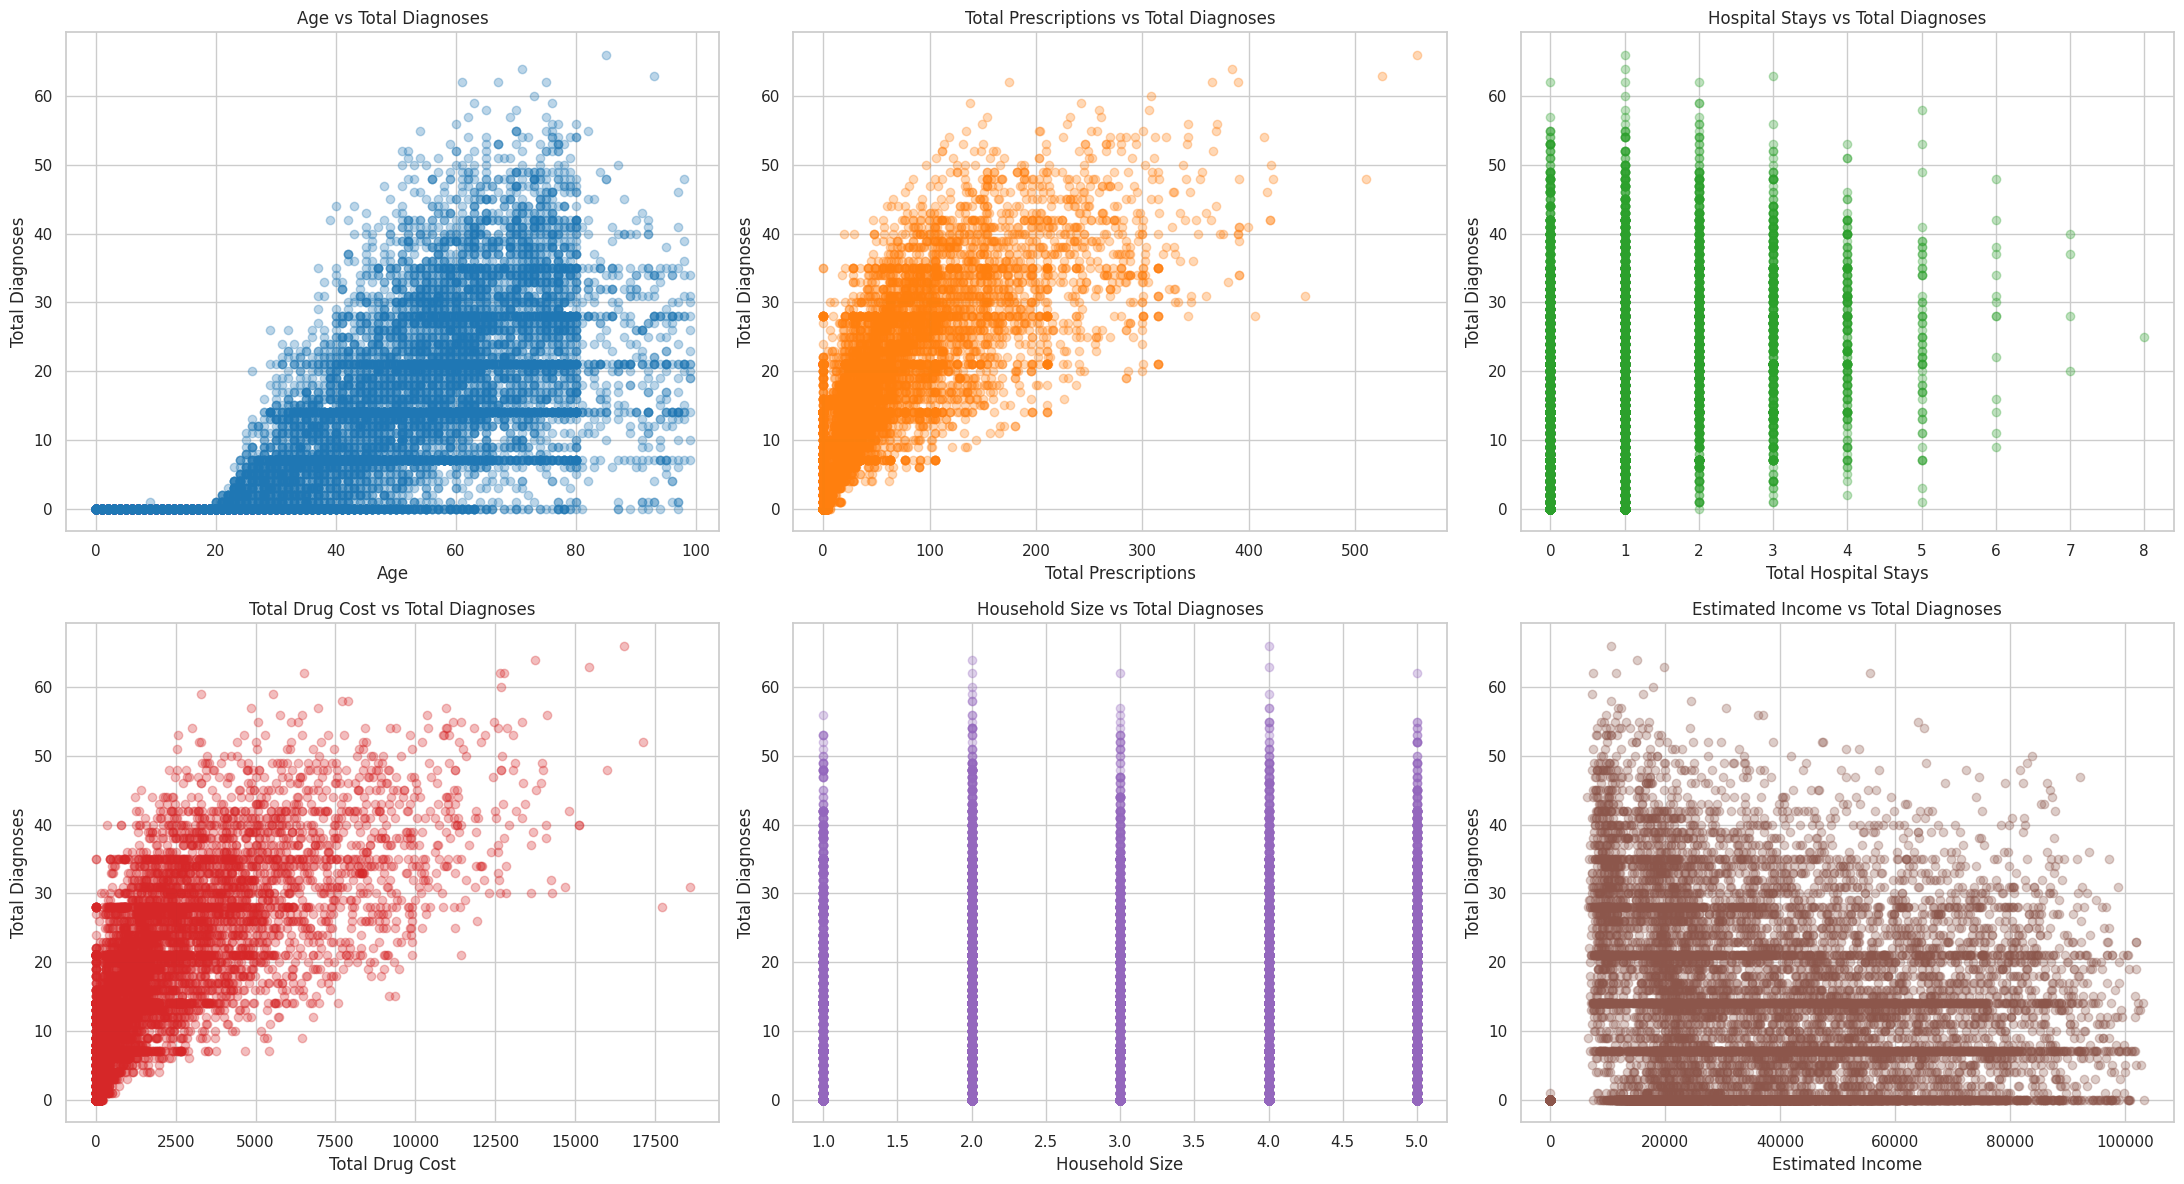

In [11]:
import matplotlib.pyplot as plt

# Expand the grid to 2 rows and 3 columns to consider all 6 key variables
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# Row 1, Column 0: Age vs Total Diagnoses
axes[0, 0].scatter(df_work['age'], df_work['total_diagnoses'], alpha=0.3, color='#1f77b4')
axes[0, 0].set_title('Age vs Total Diagnoses')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Total Diagnoses')

# Row 1, Column 1: Total Prescriptions vs Total Diagnoses
axes[0, 1].scatter(df_work['total_prescriptions'], df_work['total_diagnoses'], alpha=0.3, color='#ff7f0e')
axes[0, 1].set_title('Total Prescriptions vs Total Diagnoses')
axes[0, 1].set_xlabel('Total Prescriptions')
axes[0, 1].set_ylabel('Total Diagnoses')

# Row 1, Column 2: Total Hospital Stays vs Total Diagnoses
axes[0, 2].scatter(df_work['total_hospital_stays'], df_work['total_diagnoses'], alpha=0.3, color='#2ca02c')
axes[0, 2].set_title('Hospital Stays vs Total Diagnoses')
axes[0, 2].set_xlabel('Total Hospital Stays')
axes[0, 2].set_ylabel('Total Diagnoses')

# Row 2, Column 0: Total Drug Cost vs Total Diagnoses
axes[1, 0].scatter(df_work['total_drug_cost'], df_work['total_diagnoses'], alpha=0.3, color='#d62728')
axes[1, 0].set_title('Total Drug Cost vs Total Diagnoses')
axes[1, 0].set_xlabel('Total Drug Cost')
axes[1, 0].set_ylabel('Total Diagnoses')

# Row 2, Column 1: Household Size vs Total Diagnoses
axes[1, 1].scatter(df_work['household_size'], df_work['total_diagnoses'], alpha=0.3, color='#9467bd')
axes[1, 1].set_title('Household Size vs Total Diagnoses')
axes[1, 1].set_xlabel('Household Size')
axes[1, 1].set_ylabel('Total Diagnoses')

# Row 2, Column 2: Estimated Income vs Total Diagnoses
axes[1, 2].scatter(df_work['estimated_income'], df_work['total_diagnoses'], alpha=0.3, color='#8c564b')
axes[1, 2].set_title('Estimated Income vs Total Diagnoses')
axes[1, 2].set_xlabel('Estimated Income')
axes[1, 2].set_ylabel('Total Diagnoses')

plt.tight_layout()
plt.show()


# Histograms or Kernel Density Estimate (KDE) plots. (Data distribution)

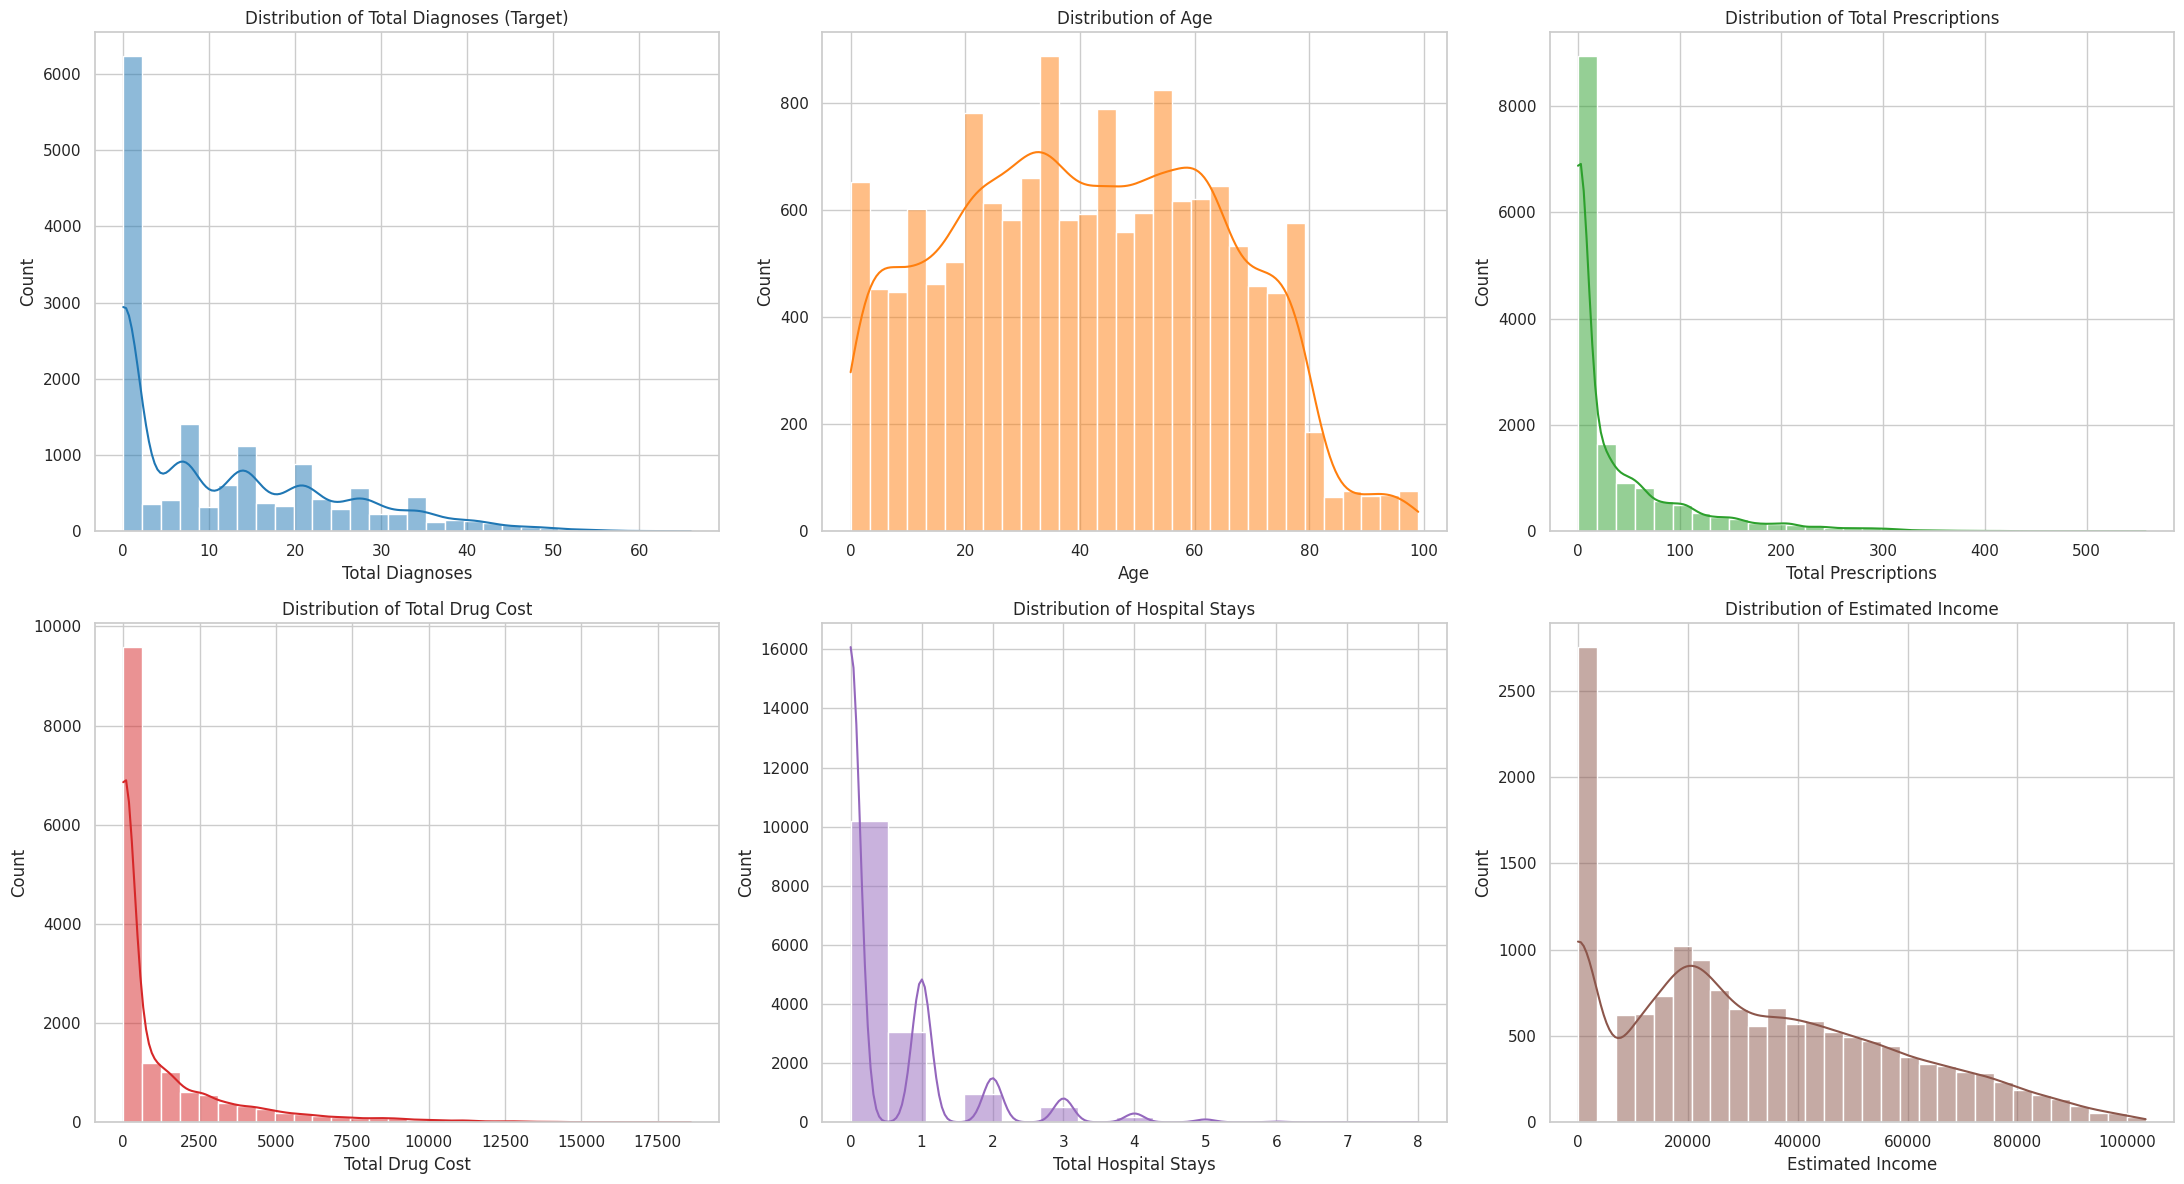

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x3 grid to look at the individual distributions of the 6 key variables
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# 1. Target Distribution: Total Diagnoses
sns.histplot(df_work['total_diagnoses'], kde=True, ax=axes[0, 0], color='#1f77b4', bins=30)
axes[0, 0].set_title('Distribution of Total Diagnoses (Target)')
axes[0, 0].set_xlabel('Total Diagnoses')

# 2. Feature Distribution: Age
sns.histplot(df_work['age'], kde=True, ax=axes[0, 1], color='#ff7f0e', bins=30)
axes[0, 1].set_title('Distribution of Age')
axes[0, 1].set_xlabel('Age')

# 3. Feature Distribution: Total Prescriptions
sns.histplot(df_work['total_prescriptions'], kde=True, ax=axes[0, 2], color='#2ca02c', bins=30)
axes[0, 2].set_title('Distribution of Total Prescriptions')
axes[0, 2].set_xlabel('Total Prescriptions')

# 4. Feature Distribution: Total Drug Cost
sns.histplot(df_work['total_drug_cost'], kde=True, ax=axes[1, 0], color='#d62728', bins=30)
axes[1, 0].set_title('Distribution of Total Drug Cost')
axes[1, 0].set_xlabel('Total Drug Cost')

# 5. Feature Distribution: Total Hospital Stays
sns.histplot(df_work['total_hospital_stays'], kde=True, ax=axes[1, 1], color='#9467bd', bins=15)
axes[1, 1].set_title('Distribution of Hospital Stays')
axes[1, 1].set_xlabel('Total Hospital Stays')

# 6. Feature Distribution: Estimated Income
sns.histplot(df_work['estimated_income'], kde=True, ax=axes[1, 2], color='#8c564b', bins=30)
axes[1, 2].set_title('Distribution of Estimated Income')
axes[1, 2].set_xlabel('Estimated Income')

plt.tight_layout()
plt.show()


# Right-Skewness (The Long Tail):
Columns like **total_drug_cost**, **total_prescriptions**, and **total_hospital_stays** typically exhibit a heavy right-skew, where a large portion of the population clusters near zero, but a few high-cost/high-utilization individuals pull the tail far to the right. If confirmed, this confirms that a **np.log1p()** transformation is highly beneficial for **linear models.Bimodal** or **Uniform Distributions**: age or estimated_income might show multiple peaks or a more balanced bell curve shape, which linear models can process cleanly without intensive scaling transformation.

In [13]:
# Compute descriptive statistics and skewness to check the distribution numerically
print("📝 --- NUMERICAL DISTRIBUTION ANALYSIS ---")
for col in ['total_diagnoses', 'age', 'total_prescriptions', 'total_drug_cost', 'total_hospital_stays', 'estimated_income']:
    skew_val = df_work[col].skew()
    print(f"🔹 Column '{col}':")
    print(f"   Mean: {df_work[col].mean():.2f}  |  Median: {df_work[col].median():.2f}")
    print(f"   Min:  {df_work[col].min():.2f}   |  Max:    {df_work[col].max():.2f}")
    print(f"   Skewness Score: {skew_val:.2f}")

    # Interpretation of skewness
    if skew_val > 1:
        print("   ⚠️ Distribution Shape: Highly Right-Skewed (Long tail to the right)")
    elif skew_val < -1:
        print("   ⚠️ Distribution Shape: Highly Left-Skewed (Long tail to the left)")
    else:
        print("   ✅ Distribution Shape: Fairly Symmetrical / Normal")
    print("-" * 50)


📝 --- NUMERICAL DISTRIBUTION ANALYSIS ---
🔹 Column 'total_diagnoses':
   Mean: 11.04  |  Median: 7.00
   Min:  0.00   |  Max:    66.00
   Skewness Score: 1.05
   ⚠️ Distribution Shape: Highly Right-Skewed (Long tail to the right)
--------------------------------------------------
🔹 Column 'age':
   Mean: 41.31  |  Median: 41.00
   Min:  0.00   |  Max:    99.00
   Skewness Score: 0.08
   ✅ Distribution Shape: Fairly Symmetrical / Normal
--------------------------------------------------
🔹 Column 'total_prescriptions':
   Mean: 37.01  |  Median: 3.00
   Min:  0.00   |  Max:    558.00
   Skewness Score: 2.44
   ⚠️ Distribution Shape: Highly Right-Skewed (Long tail to the right)
--------------------------------------------------
🔹 Column 'total_drug_cost':
   Mean: 1208.47  |  Median: 58.50
   Min:  0.00   |  Max:    18586.31
   Skewness Score: 2.65
   ⚠️ Distribution Shape: Highly Right-Skewed (Long tail to the right)
--------------------------------------------------
🔹 Column 'total_hosp

# 💡 How to Read the Text OutputSkewness

**Score > 1:** The mean is much higher than the median. This indicates a massive cluster of data points on the lower end with a long, thin tail extending toward very high values. Columns showing this pattern (often healthcare utilization and cost metrics) typically require a np.log1p() transformation before training linear models.

**Skewness Score between -1 and 1:** The values are evenly balanced around the center. This indicates the column is safe to use with standard scaling (like standard normalization).

# 🔍 Detailed Analysis of the "Weird" ShapesTotal Diagnoses

### (Target - Top Left):
* There is a massive spike exactly at 0 (thousands of rows have zero diagnoses), followed by a gap, and then a multi-modal wave pattern (peaks around 8, 15, and 23).
* This indicates the population is split: a huge group has no recorded illnesses, while the chronic-illness group has distinct clusters of diagnosis counts.

### Total Prescriptions & Total Drug Cost (Top Right & Bottom Left):
* These columns are extremely squashed against the left wall. A vast majority of patients have 0 or near-zero prescriptions and costs, while a tiny handful of outlier patients stretch the tail out to 500+ prescriptions and $17,500+ in drug costs.
* This massive scale difference (0 vs. 17,500) forces scatter plots to compress all standard data points into an unreadable vertical or horizontal cluster.

### Estimated Income (Bottom Right):
* There is a distinct, unnatural spike at exactly 0, followed by a more standard, right-skewed curve peaking around \$20,000. A true income of exactly $0 for thousands of individuals usually indicates a specific coding placeholder in the data (e.g., unemployed individuals, children, or missing data records encoded as 0).
* Hospital Stays (Bottom Middle):This is a discrete count variable. Over 14,000 records sit at exactly 0. The remaining values drop off sharply at 1, 2, 3, etc.

# 💻 Execution Code: Log Transform and Re-Plot

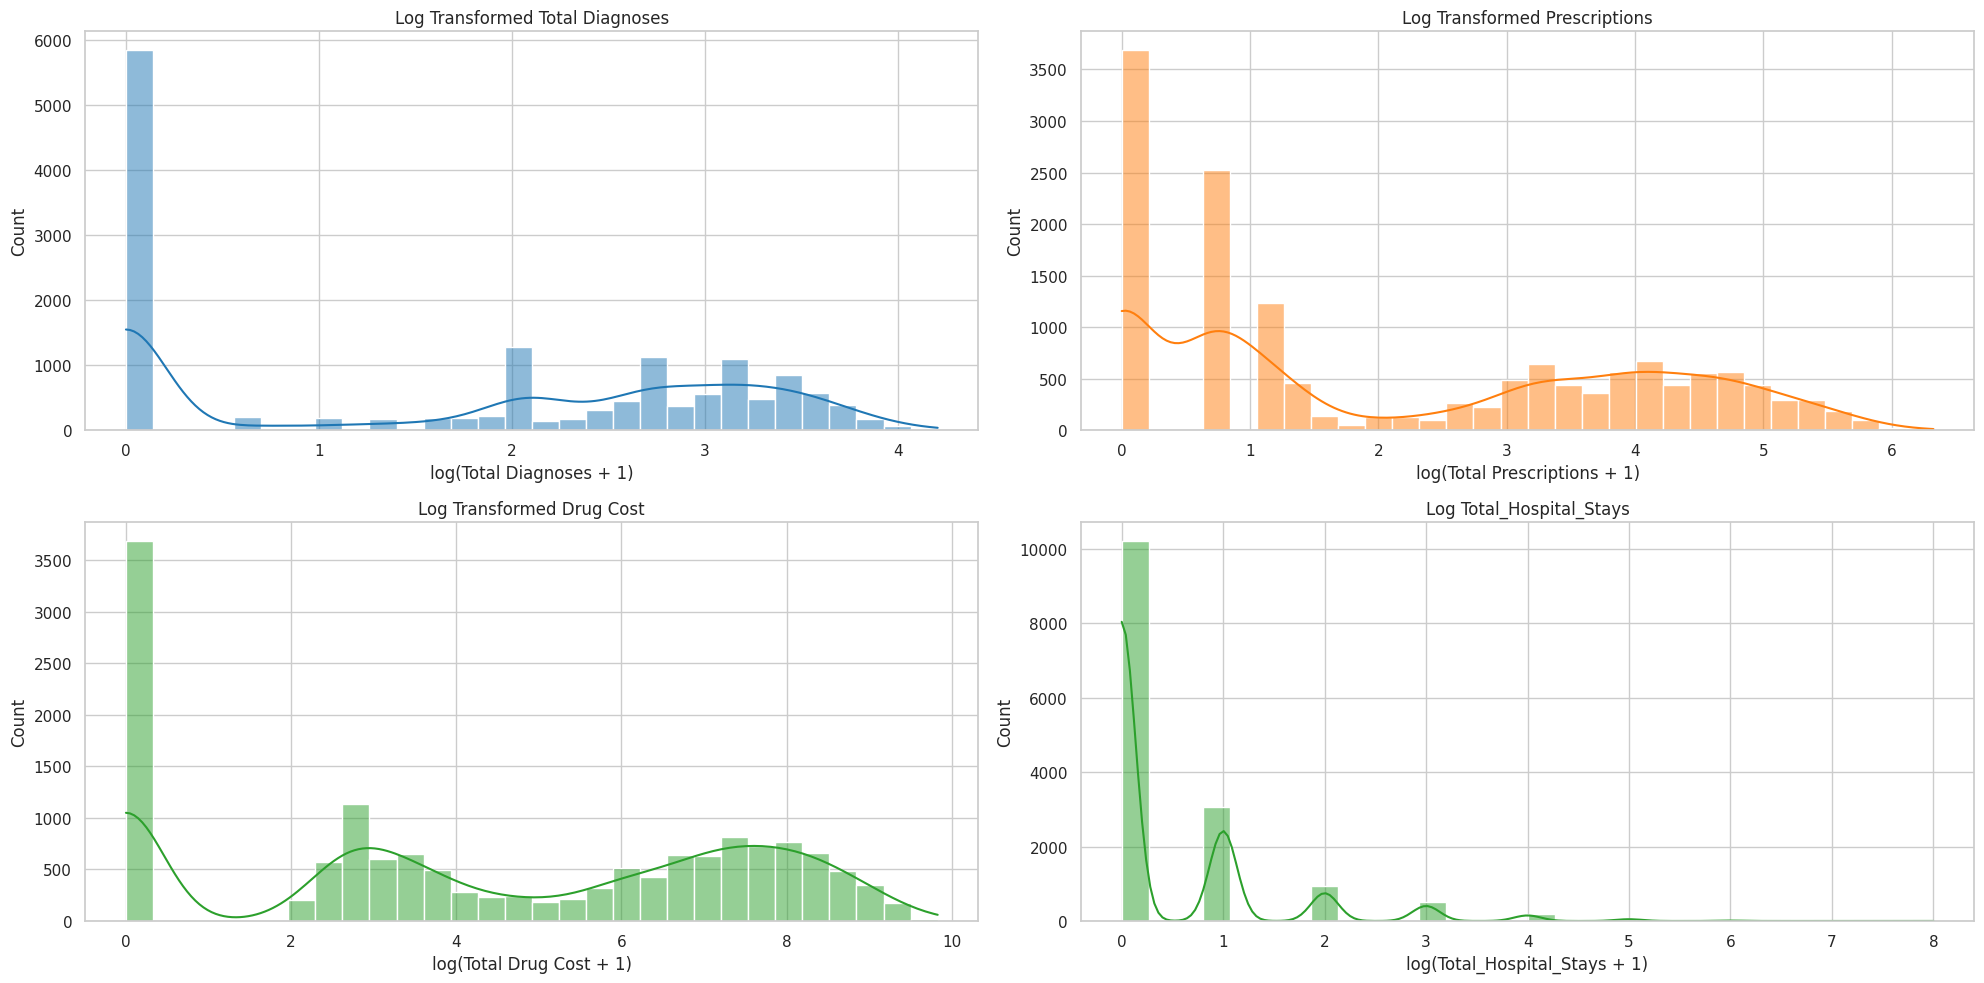

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy to test the transformations
df_log = df_work.copy()

# Apply log(x + 1) to highly skewed columns
skewed_cols = ['total_diagnoses', 'total_prescriptions', 'total_drug_cost']
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col])

# Re-plot the transformed distributions side-by-side
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.histplot(df_log['total_diagnoses'], kde=True, ax=axes[0,0], color='#1f77b4', bins=30)
axes[0,0].set_title('Log Transformed Total Diagnoses')
axes[0,0].set_xlabel('log(Total Diagnoses + 1)')

sns.histplot(df_log['total_prescriptions'], kde=True, ax=axes[0,1], color='#ff7f0e', bins=30)
axes[0,1].set_title('Log Transformed Prescriptions')
axes[0,1].set_xlabel('log(Total Prescriptions + 1)')

sns.histplot(df_log['total_drug_cost'], kde=True, ax=axes[1,0], color='#2ca02c', bins=30)
axes[1,0].set_title('Log Transformed Drug Cost')
axes[1,0].set_xlabel('log(Total Drug Cost + 1)')

sns.histplot(df_log['total_hospital_stays'], kde=True, ax=axes[1,1], color='#2ca02c', bins=30)
axes[1,1].set_title('Log Total_Hospital_Stays')
axes[1,1].set_xlabel('log(Total_Hospital_Stays + 1)')

plt.tight_layout()
plt.show()


# 📊 Structural Insights from the Transformed DistributionsClear Zero-Inflated Subpopulations:

In all four plots, a massive spike remains at exactly 0 (which maps to log(0 + 1) = 0).
* The transformation separates the dataset into two clear clinical cohorts: an unexposed/healthy cohort at 0, and an active healthcare cohort forming the rounded curves to the right.

* Emergence of Multi-Modal Bell Curves:Log Total Prescriptions & Log Drug Cost: The data points that were previously squished against the left wall now form beautiful, clean, near-normal distributions stretching between 2 and 6 (for prescriptions) and 2 and 10 (for drug costs).Log Total Diagnoses: The chronic illness cohort now forms a clear normal curve centered around a value of 3 (representing roughly 19 diagnoses).

# 🛠️ Next Architectural Modeling Decisions

Because standard models struggle to predict a single continuous value when a massive portion of the data sits precisely at zero, two professional modeling pathways are available to proceed:
* Pathway A:Two-Stage Hurdle Model (Recommended for Deepest Insights)
Instead of forcing a single regression model to guess both the zeros and the continuous curves simultaneously, the problem is split into two distinct steps:

1. Classifier Stage: Train a binary classification model (e.g., Logistic Regression or LightGBM) to predict whether a patient will have zero diagnoses vs. at least one diagnosis (total_diagnoses > 0).
2. Regressor Stage: Filter the dataset to only include rows where total_diagnoses > 0, and train a regression model (e.g., Ridge Regression or Random Forest) to predict the exact log-transformed diagnosis count for that active group.

* Pathway B: Tree-Based Gradient Boosting (Simplest Implementation)If a single model workflow is preferred, linear regression should be bypassed. Non-linear algorithms like XGBoost, LightGBM, or Random Forests naturally handle zero-inflated multi-modal distributions without getting thrown off by the large zero spike.

#⚰️ Phase 2: Relationships with Binary Targets (is_deceased)
<p>Because is_deceased is 0 or 1, standard scatter plots will look like two flat lines of dots and won't be helpful. Use these instead:</p>

<h1>A. Continuous Features vs. is_deceased (Histograms / KDE Plots)</h1>
<h2>Method:</h2> <p>Plot an overlapped kernel density estimation (KDE) plot or histogram of a continuous variable (like age or estimated_income), colored by whether is_deceased is 0 or 1.</p>
<h2>What to look for:</h2> <p>You should see a clear divergence in the age distribution—the curve for is_deceased=1 should lean heavily toward older ages compared to is_deceased=0.<p/>

<h1>B. Discrete/Categorical Features vs. is_deceased (Stacked Bar Charts / Proportions)</h1>
<h2>Method:</h2> <p>alculate the mortality rate (mean of is_deceased) across different categorical groups.</p>
<h2>What to look for:</h2> <p>What percentage of individuals in region X are deceased compared to region Y? Is there a visible gap in mortality rates between urban and rural populations?</p>

# 📊 Exploratory Data Analysis (EDA):

## Phase 2 — Relationships with Binary Targets (is_deceased)
### 💡 Motivation & Objective
The second target variable, is_deceased, is binary (0 representing surviving individuals and 1 representing deceased individuals). Because a binary variable sits at only two discrete coordinates, standard continuous scatter plots fail to show density or trends.Analyzing features against a binary outcome requires evaluating how data distributions shift or how proportions change between the two target states. This step provides essential insights into mortality risk indicators, laying the foundation for a binary classification pipeline.

# 💻 Execution Code for Phase 2A & 2B
The following script implements both analytical approaches:
## Phase 2A:
Generates overlaid Kernel Density Estimate (KDE) plots for continuous features (age and estimated_income), splitting the distributions by the survival outcome to highlight structural shifts.Phase 2B: Computes and plots the exact mortality rate (the proportion of is_deceased == 1) across key discrete groups (urban_rural and income_quartile).

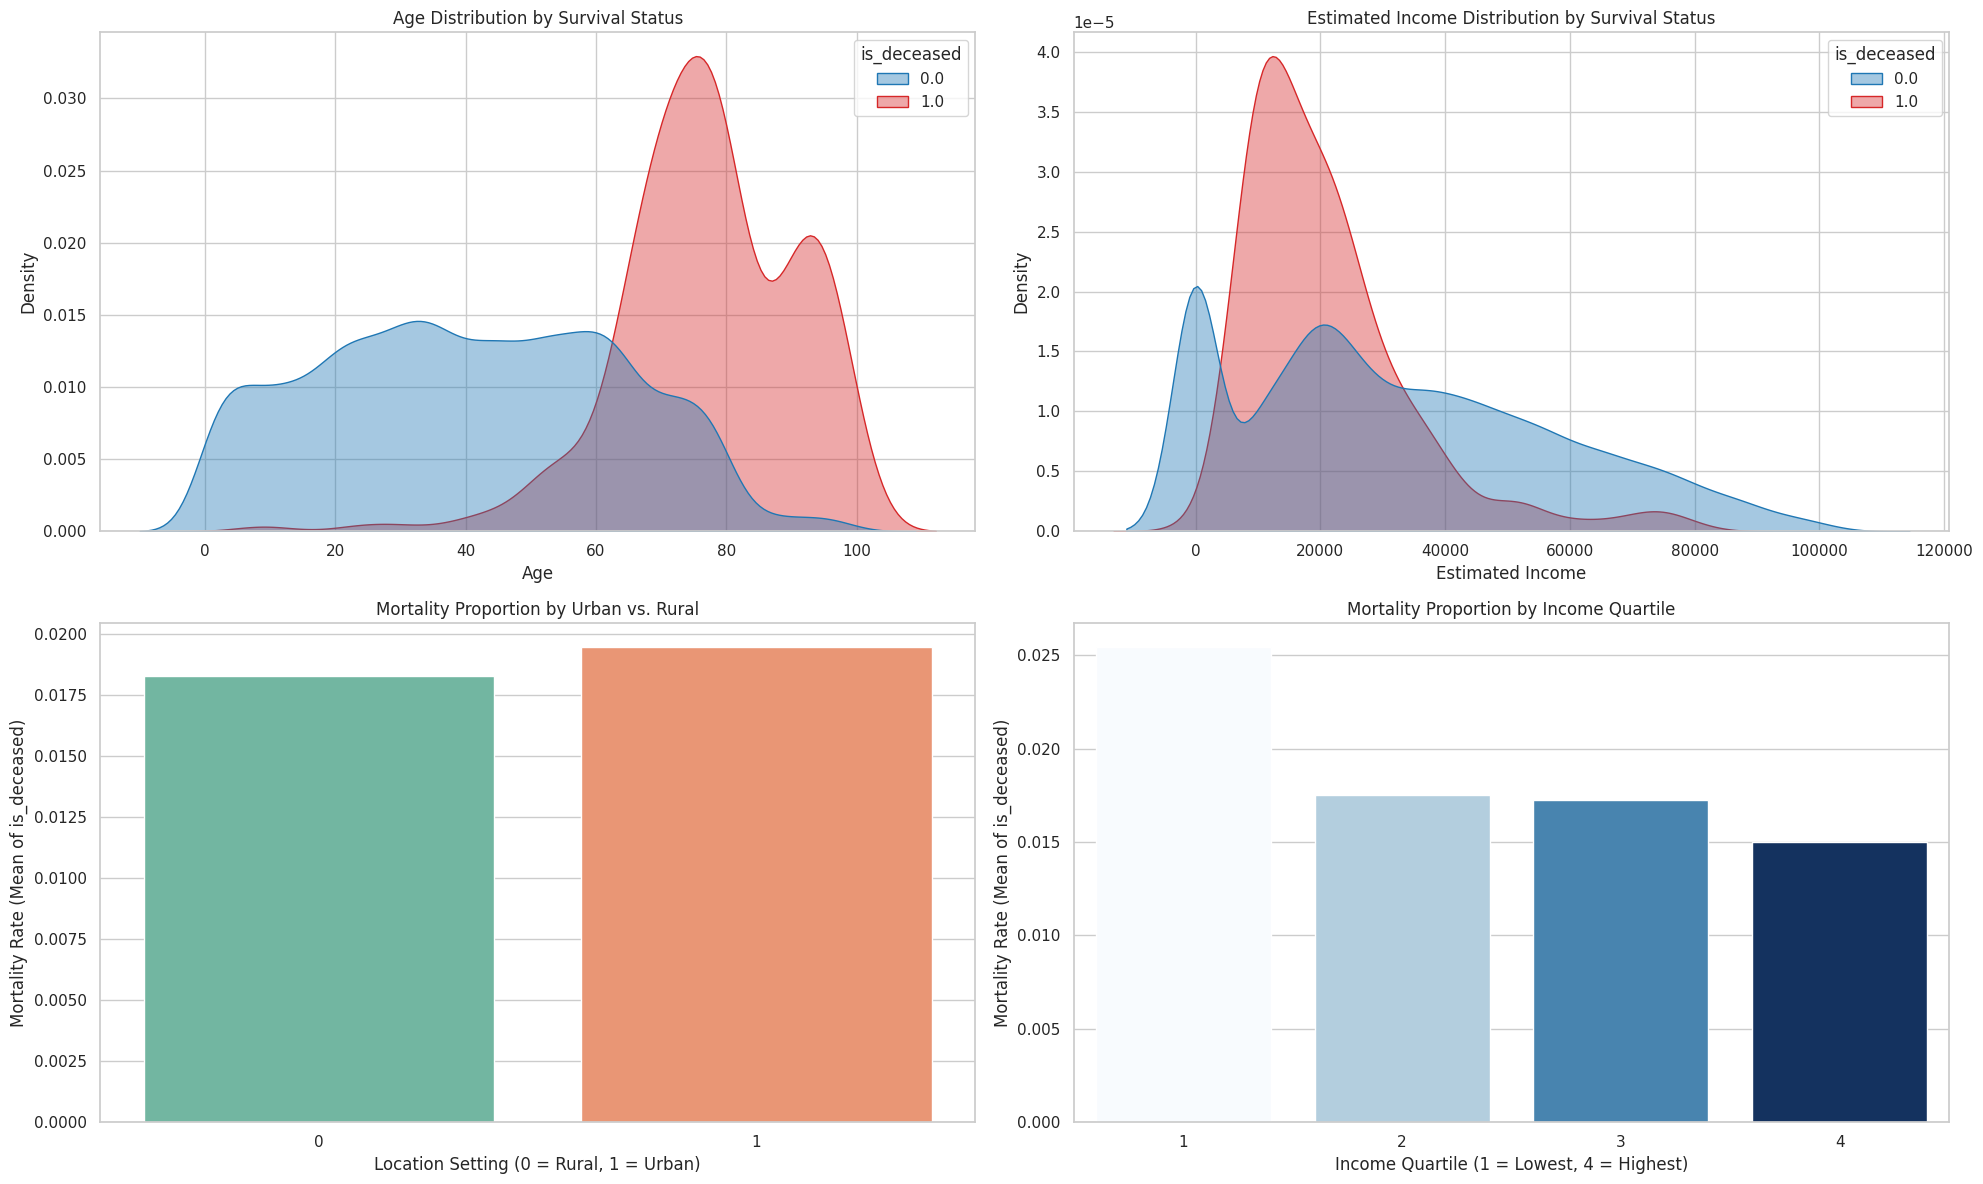

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure a 2x2 grid for a comprehensive binary relationship overview
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# ==========================================
# PHASE 2A: Continuous Features vs. is_deceased
# ==========================================

# Plot 1: Age Distribution by Survival Status
sns.kdeplot(data=df_work, x='age', hue='is_deceased', fill=True, common_norm=False,
            palette=['#1f77b4', '#d62728'], alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Survival Status')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Density')

# Plot 2: Estimated Income Distribution by Survival Status
sns.kdeplot(data=df_work, x='estimated_income', hue='is_deceased', fill=True, common_norm=False,
            palette=['#1f77b4', '#d62728'], alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title('Estimated Income Distribution by Survival Status')
axes[0, 1].set_xlabel('Estimated Income')
axes[0, 1].set_ylabel('Density')

# ==========================================
# PHASE 2B: Discrete Features vs. is_deceased
# ==========================================

# Plot 3: Mortality Rate by Urban/Rural Setting
# FIX: Assigned x variable to hue and set legend=False to silence warnings
sns.barplot(data=df_work, x='urban_rural', y='is_deceased', hue='urban_rural',
            legend=False, ax=axes[1, 0], palette='Set2', errorbar=None)
axes[1, 0].set_title('Mortality Proportion by Urban vs. Rural')
axes[1, 0].set_xlabel('Location Setting (0 = Rural, 1 = Urban)')
axes[1, 0].set_ylabel('Mortality Rate (Mean of is_deceased)')

# Plot 4: Mortality Rate by Income Quartile
# FIX: Assigned x variable to hue and set legend=False to silence warnings
sns.barplot(data=df_work, x='income_quartile', y='is_deceased', hue='income_quartile',
            legend=False, ax=axes[1, 1], palette='Blues', errorbar=None)
axes[1, 1].set_title('Mortality Proportion by Income Quartile')
axes[1, 1].set_xlabel('Income Quartile (1 = Lowest, 4 = Highest)')
axes[1, 1].set_ylabel('Mortality Rate (Mean of is_deceased)')

plt.tight_layout()
plt.show()


# 🔍 Structural Indicators to Evaluate in the Output:
## Age Separation:
Check if the red curve (is_deceased=1) displays a stark shift toward the right side of the x-axis, confirming higher baseline risk in older cohorts.
## Income Curve Anomalies:
Observe the peak at zero income. Inspect whether the mortality density is disproportionately higher at that exact zero mark compared to the rest of the income scale.Socioeconomic Disparities: Examine the bar charts to determine if lower income quartiles or specific urban/rural settings correlate with a higher average mortality rate.

# 🔍 Detailed Analysis of the Binary Trends1.
## 1. Age Distribution by Survival Status (Top Left)Stark Separation:
* There is an exceptionally clear divergence between the two cohorts. The living population (is_deceased = 0.0 in blue) is evenly spread across ages 0 to 60 before dropping off.
* Late-Life Peak: The deceased population (is_deceased = 1.0 in red) forms a massive, multi-modal spike starting around age 60, peaking heavily at age 75, with a secondary peak around age 95. This establishes age as one of the most powerful predictive features for the upcoming classification task.

## 2. Estimated Income Distribution by Survival Status (Top Right)
* The Zero-Income Phenomenon: The blue distribution (surviving cohort) shows a high density peak clustered exactly at \$0 income. Conversely, the red distribution (deceased cohort) drops off sharply to nearly zero at the \$0 mark.
* Income Concentration: The deceased population is highly concentrated in a tight peak between \$10,000 and $25,000. It quickly thins out as income rises, indicating that higher income brackets have a significantly lower density of deceased records.

## 3. Mortality Proportion by Urban vs. Rural (Bottom Left)
* Slight Geographic Variance: The average mortality rate in rural settings (0) hovers around 1.8%, while urban environments (1) show a slightly higher rate approaching 1.95%. While a difference exists, the gap is small, indicating that geography is a mild discriminator on its own.

## 4. Mortality Proportion by Income Quartile (Bottom Left)Socioeconomic Gradient:
A clear, step-down pattern emerges across income tiers. The lowest income quartile (Q1 / value 1) shows the highest mortality rate at approximately 2.5%.Consistent Decrease: As the income quartile increases to 2, 3, and 4, the mortality rate drops incrementally, reaching its lowest point (around 1.5%) in the highest income tier (Q4). This confirms a strong inverse relationship between socioeconomic standing and baseline mortality risk.

################################################################################################################################################################

# 💻 Execution Code: Automated Outlier Diagnostic (Outlier)
The following script executes a dual check. It computes the statistical outlier volume for the continuous variables using the IQR method, and displays frequency tables for categorical variables to reveal rare groups

# 📈 1. Continuous Features (Primary Focus)
Continuous features (such as estimated_income, total_prescriptions, and total_drug_cost) are the most vulnerable to outliers. Extreme values distort statistical calculations like the mean and standard deviation, which can destabilize linear machine learning models. [1] (https://www.youtube.com/watch?v=TBtBbAj53-k)

* The Approach: Use statistical thresholds like the Interquartile Range (IQR) method (values outside 1.5 \(\times \) IQR from the 25th/75th percentiles) or Z-score boundaries (values more than 3 standard deviations from the mean). [1] (https://www.geeksforgeeks.org/machine-learning/machine-learning-outlier/)

* Current State in the Dataset: The log-transformation step already mitigated the operational impact of right-skewed extremes in total_prescriptions and total_drug_cost by compressing the mathematical distance of those long tails. [1] (https://www.youtube.com/watch?v=SPHRbk3mcWE&t=64), [2] (https://medium.com/@mehul.chourasia28/handling-outliers-a-comprehensive-guide-to-data-cleaning-3a0589c0b366)

# 🏷️ 2. Discrete & Categorical Features (Data Quality Focus)
In pure text or low-count discrete columns (such as sex, urban_rural, or income_quartile), an "outlier" does not manifest as a massive numerical value. Instead, an outlier signifies a data quality anomaly, a rare category, or an impossible value. [1] (https://towardsdatascience.com/encoding-categorical-data-for-outlier-detection/), [2] (https://www.youtube.com/watch?v=1cE5OQQmx3Q&t=902)

* What to check for:Frequency Anomalies: Categories with an extremely low representation. For example, if a column contains 15,000 records of category A and only 2 records of category B, category B is a categorical outlier. A machine learning model cannot learn stable patterns from 2 examples and may overfit.Logical

* Violations: Values that defy domain constraints, such as a household_size of -1, an age of 150, or a string category that does not belong in the column (e.g., a typo like ['M', 'F', 'Unknown_Value_XYZ']).

* The Approach: Review the unique value counts via value distributions to ensure small, unrepresentative classes are either grouped into an 'Other' bucket or flagged for exclusion. [1] (https://medium.com/@mehul.chourasia28/handling-outliers-a-comprehensive-guide-to-data-cleaning-3a0589c0b366)

In [24]:
import pandas as pd
import numpy as np

print("📊 === CONTINUOUS OUTLIER CHECK (IQR Method) ===")
# These columns still exist as continuous numeric values in df_work
continuous_check = ['age', 'estimated_income', 'total_prescriptions', 'total_drug_cost']

for col in continuous_check:
    Q1 = df_work[col].quantile(0.25)
    Q3 = df_work[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify entries outside the fences
    outliers = df_work[(df_work[col] < lower_bound) | (df_work[col] > upper_bound)]
    pct_outliers = (len(outliers) / len(df_work)) * 100

    print(f"🔹 Column '{col}':")
    print(f"   Fences: [{lower_bound:.2f} to {upper_bound:.2f}]")
    print(f"   Outlier Count: {len(outliers)} rows ({pct_outliers:.2f}%)")
    print("-" * 50)

print("\n🏷️ === DISCRETE/ENCODED BINARY FREQUENCY CHECK ===")
# Check the already mapped/encoded discrete variables to spot rare categories
discrete_check = ['sex', 'urban_rural', 'income_quartile', 'education']

for col in discrete_check:
    print(f"🔹 Distribution Proportions for '{col}':")
    frequencies = df_work[col].value_counts(dropna=False)
    proportions = df_work[col].value_counts(normalize=True, dropna=False) * 100

    for idx in frequencies.index:
        print(f"   Value [{idx}]: Count = {frequencies[idx]} ({proportions[idx]:.2f}%)")
    print("-" * 50)


📊 === CONTINUOUS OUTLIER CHECK (IQR Method) ===
🔹 Column 'age':
   Fences: [-32.50 to 115.50]
   Outlier Count: 0 rows (0.00%)
--------------------------------------------------
🔹 Column 'estimated_income':
   Fences: [-44231.12 to 106033.88]
   Outlier Count: 0 rows (0.00%)
--------------------------------------------------
🔹 Column 'total_prescriptions':
   Fences: [-71.00 to 121.00]
   Outlier Count: 1410 rows (9.40%)
--------------------------------------------------
🔹 Column 'total_drug_cost':
   Fences: [-2216.26 to 3714.32]
   Outlier Count: 1653 rows (11.02%)
--------------------------------------------------

🏷️ === DISCRETE/ENCODED BINARY FREQUENCY CHECK ===
🔹 Distribution Proportions for 'sex':
   Value [0]: Count = 7658 (51.05%)
   Value [1]: Count = 7342 (48.95%)
--------------------------------------------------
🔹 Distribution Proportions for 'urban_rural':
   Value [1]: Count = 9756 (65.04%)
   Value [0]: Count = 5244 (34.96%)
--------------------------------------------